In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Path to your synced Google Drive folder
file_path = '/content/drive/My Drive/Dataset_Journal/Mozilla_bugs_new.csv'

df = pd.read_csv(file_path, encoding='latin1')

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   BugID                                          Summary    Status  \
0    137                 Compilation : wrong library Path  VERIFIED   
1    137                 Compilation : wrong library Path  VERIFIED   
2    137                 Compilation : wrong library Path  VERIFIED   
3    137                 Compilation : wrong library Path  VERIFIED   
4    145  linebreaks lost in PRE within fixed-width table  VERIFIED   

  Resolution Priority Severity                      Creator  \
0      FIXED       P3  trivial  Hubert.Figuiere@solsoft.com   
1      FIXED       P3  trivial  Hubert.Figuiere@solsoft.com   
2      FIXED       P3  trivial  Hubert.Figuiere@solsoft.com   
3      FIXED       P3  trivial  Hubert.Figuiere@solsoft.com   
4      FIXED       P3   normal  dkindred=mozilla@cs.cmu.edu   

                   AssignedTo          CreationTime        LastChangeTime  \
0            ramiro@eazel.com  1998-04-10T19:45:25Z  2018-10-12T15:23:05Z   
1          

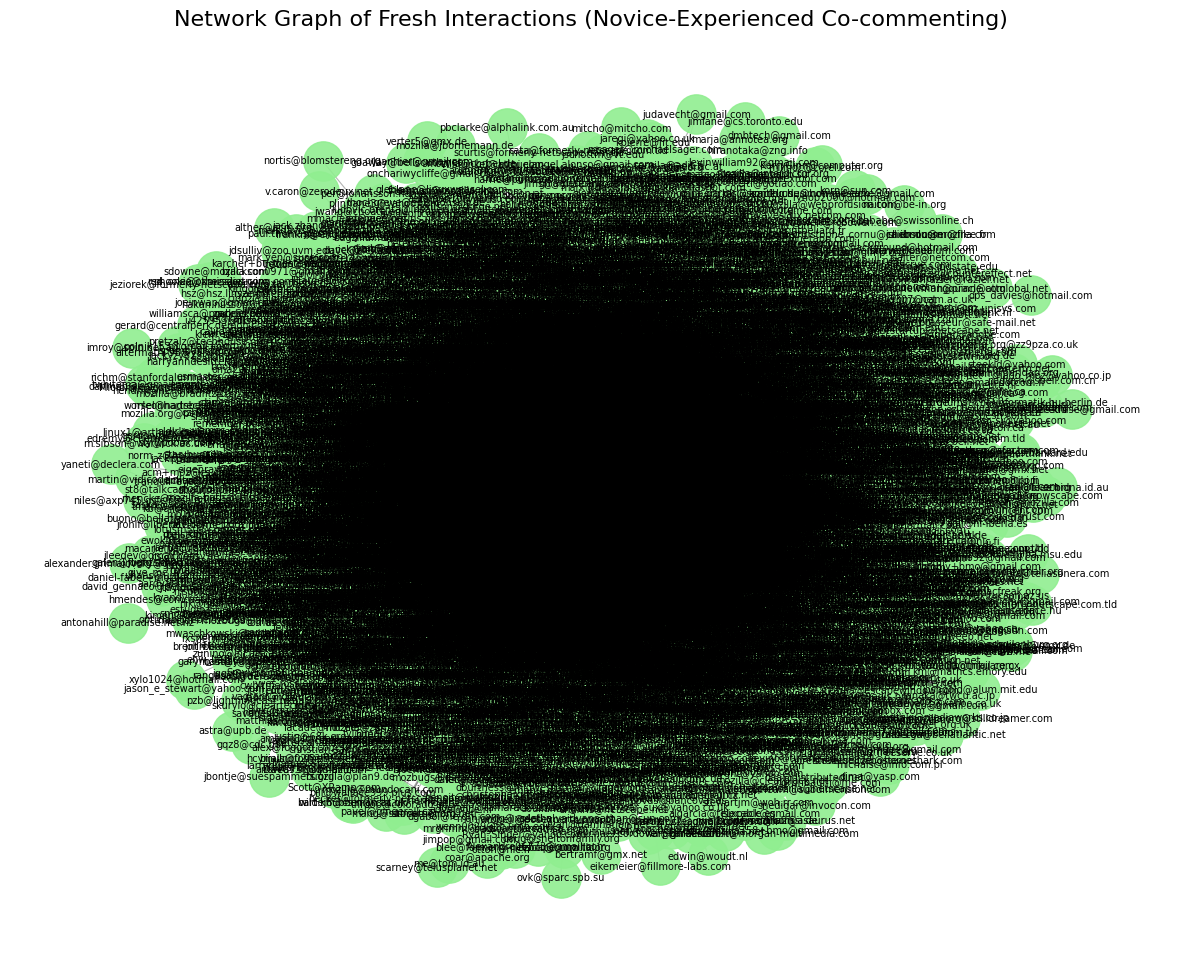

Number of nodes (developers in Fresh Interactions): 10420
Number of edges (Fresh Interaction pairs): 251301


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Re-initialize tracking variables to correctly identify fresh interaction pairs
developer_first_comment_time_graph = {}
fresh_interaction_edges = set() # To store frozensets of (novice, experienced) pairs

# Get unique BugIDs sorted by their earliest comment time from the sorted DataFrame
bug_earliest_comment_times_graph = df.groupby('BugID')['CommentTime'].min().sort_values()

# Iterate through bugs chronologically to determine interaction types and collect fresh interaction pairs
for bug_id in bug_earliest_comment_times_graph.index:
    bug_comments = df[df['BugID'] == bug_id].copy()
    current_bug_comment_creators = bug_comments['CommentCreator'].unique()
    earliest_comment_on_this_bug = bug_comments['CommentTime'].min()

    current_developers_status_graph = {}
    for dev in current_bug_comment_creators:
        if dev in developer_first_comment_time_graph and developer_first_comment_time_graph[dev] < earliest_comment_on_this_bug:
            current_developers_status_graph[dev] = 'experienced'
        else:
            current_developers_status_graph[dev] = 'novice'

    # Identify FreshInteraction pairs for this bug
    # This part iterates through all unique pairs of developers who commented on the current bug
    for i, dev1 in enumerate(current_bug_comment_creators):
        for j, dev2 in enumerate(current_bug_comment_creators):
            if i >= j: # Avoid self-pairs and redundant pairs (e.g., (A,B) and (B,A))
                continue

            dev1_status = current_developers_status_graph[dev1]
            dev2_status = current_developers_status_graph[dev2]

            # Check for FreshInteraction condition: one novice, one experienced
            if (dev1_status == 'novice' and dev2_status == 'experienced') or \
               (dev1_status == 'experienced' and dev2_status == 'novice'):
                fresh_interaction_edges.add(frozenset({dev1, dev2}))

    # Update developer_first_comment_time_graph for all developers involved in this bug
    for dev in current_bug_comment_creators:
        if dev not in developer_first_comment_time_graph:
            developer_first_comment_time_graph[dev] = earliest_comment_on_this_bug
        else:
            developer_first_comment_time_graph[dev] = min(developer_first_comment_time_graph[dev], earliest_comment_on_this_bug)

# Create a NetworkX graph
G_fresh_interactions = nx.Graph()

# Add nodes and edges
for pair in fresh_interaction_edges:
    dev1, dev2 = tuple(pair) # Convert frozenset back to tuple for adding edge
    G_fresh_interactions.add_edge(dev1, dev2)

# Visualize the graph
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_fresh_interactions, k=0.15, iterations=20, seed=42) # Positions for all nodes, fixed seed for reproducibility

nx.draw_networkx_nodes(G_fresh_interactions, pos, node_size=800, node_color='lightgreen', alpha=0.9)
nx.draw_networkx_edges(G_fresh_interactions, pos, edge_color='gray', alpha=0.6, width=0.8)
nx.draw_networkx_labels(G_fresh_interactions, pos, font_size=7, font_color='black')

plt.title("Network Graph of Fresh Interactions (Novice-Experienced Co-commenting)", size=16)
plt.axis('off') # Hide axes
plt.show()

print(f"Number of nodes (developers in Fresh Interactions): {G_fresh_interactions.number_of_nodes()}")
print(f"Number of edges (Fresh Interaction pairs): {G_fresh_interactions.number_of_edges()}")

# Note on Pajek:
# NetworkX can export graphs to the Pajek format (.net or .vec) if you need to use the Pajek software.
# For example, to export:
# nx.write_pajek(G_fresh_interactions, "fresh_interactions_graph.net")

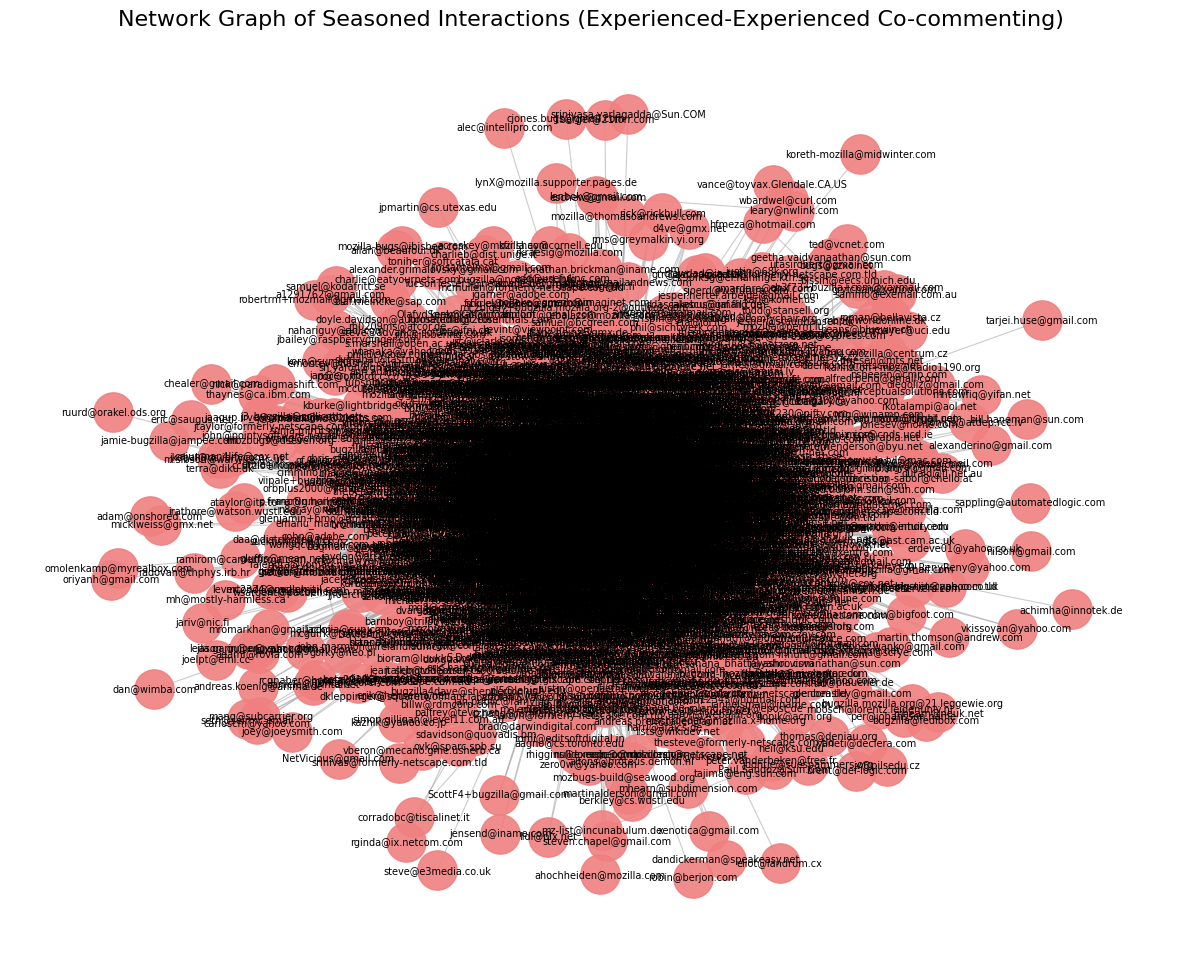

Number of nodes (developers in Seasoned Interactions): 3047
Number of edges (Seasoned Interaction pairs): 154689


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Re-initialize tracking variables for Seasoned Interactions (experienced-experienced co-commenting)
seasoned_interaction_edges = set() # To store frozensets of (experienced, experienced) pairs

# Iterate through bugs chronologically to determine interaction types and collect seasoned interaction pairs
for bug_id in bug_earliest_comment_times_graph.index:
    bug_comments = df[df['BugID'] == bug_id].copy()
    current_bug_comment_creators = bug_comments['CommentCreator'].unique()
    earliest_comment_on_this_bug = bug_comments['CommentTime'].min()

    current_developers_status_seasoned_interaction = {}
    for dev in current_bug_comment_creators:
        if dev in developer_first_comment_time_graph and developer_first_comment_time_graph[dev] < earliest_comment_on_this_bug:
            current_developers_status_seasoned_interaction[dev] = 'experienced'
        else:
            current_developers_status_seasoned_interaction[dev] = 'novice'

    # Identify SeasonedInteraction pairs for this bug (both experienced)
    for i, dev1 in enumerate(current_bug_comment_creators):
        for j, dev2 in enumerate(current_bug_comment_creators):
            if i >= j: # Avoid self-pairs and redundant pairs
                continue

            dev1_status = current_developers_status_seasoned_interaction[dev1]
            dev2_status = current_developers_status_seasoned_interaction[dev2]

            if dev1_status == 'experienced' and dev2_status == 'experienced':
                seasoned_interaction_edges.add(frozenset({dev1, dev2}))

# Create a NetworkX graph for Seasoned Interactions
G_seasoned_interactions = nx.Graph()

# Add nodes and edges
for pair in seasoned_interaction_edges:
    dev1, dev2 = tuple(pair)
    G_seasoned_interactions.add_edge(dev1, dev2)

# Visualize the graph
plt.figure(figsize=(15, 12))
pos_seasoned = nx.spring_layout(G_seasoned_interactions, k=0.15, iterations=20, seed=42) # Positions for all nodes, fixed seed for reproducibility

nx.draw_networkx_nodes(G_seasoned_interactions, pos_seasoned, node_size=800, node_color='lightcoral', alpha=0.9)
nx.draw_networkx_edges(G_seasoned_interactions, pos_seasoned, edge_color='darkgray', alpha=0.6, width=0.8)
nx.draw_networkx_labels(G_seasoned_interactions, pos_seasoned, font_size=7, font_color='black')

plt.title("Network Graph of Seasoned Interactions (Experienced-Experienced Co-commenting)", size=16)
plt.axis('off') # Hide axes
plt.show()

print(f"Number of nodes (developers in Seasoned Interactions): {G_seasoned_interactions.number_of_nodes()}")
print(f"Number of edges (Seasoned Interaction pairs): {G_seasoned_interactions.number_of_edges()}")

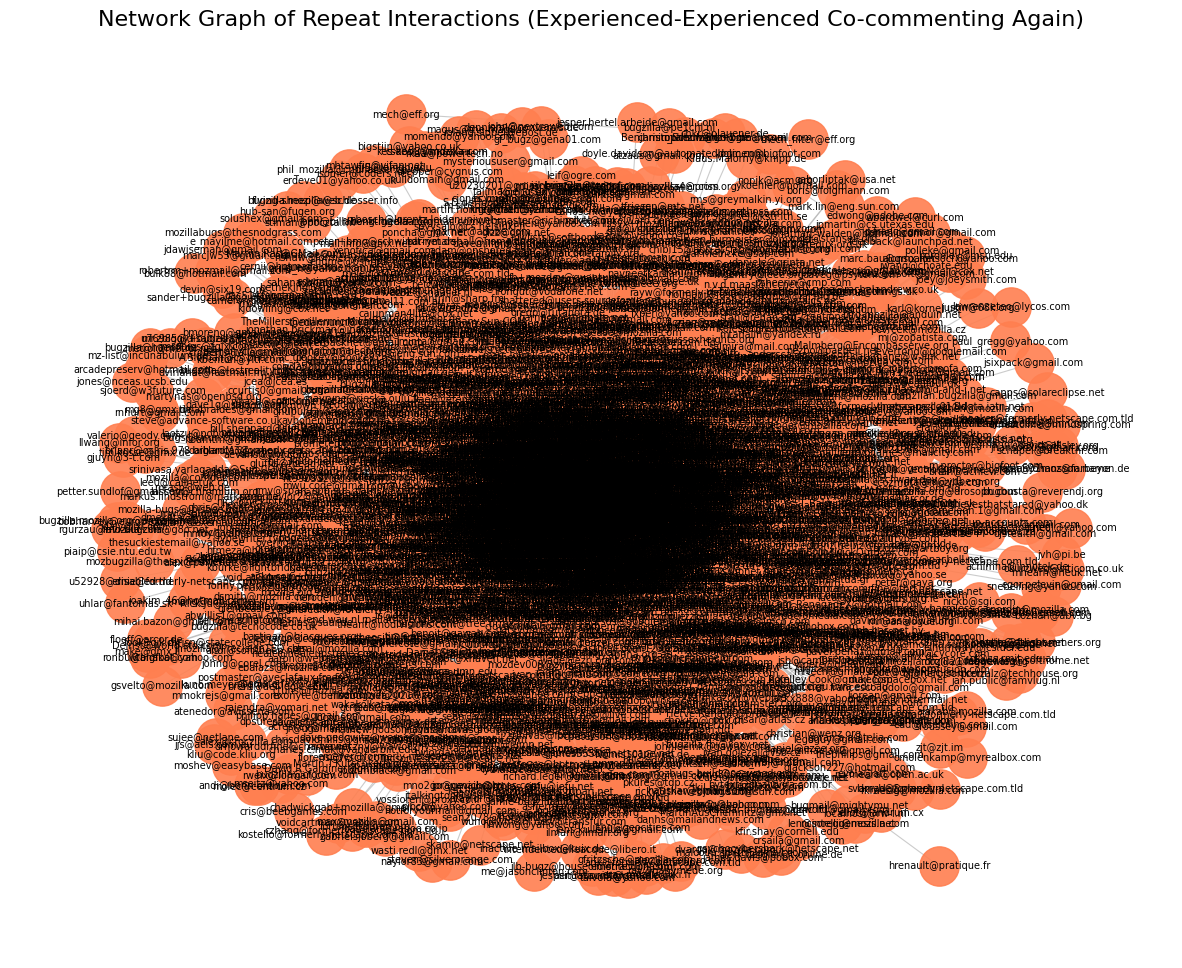

Number of nodes (developers in Repeat Interactions): 2738
Number of edges (Repeat Interaction pairs): 55359


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# global_co_commenting_history will track all pairs who have ever co-commented across all bugs
global_co_commenting_history = set()
repeat_interaction_edges = set()

# Iterate through bugs chronologically to determine interaction types and collect repeat interaction pairs
for bug_id in bug_earliest_comment_times_graph.index:
    bug_comments = df[df['BugID'] == bug_id].copy()
    current_bug_comment_creators = bug_comments['CommentCreator'].unique()
    earliest_comment_on_this_bug = bug_comments['CommentTime'].min()

    # Determine status (novice/experienced) for developers commenting on *this* bug
    current_developers_status = {}
    for dev in current_bug_comment_creators:
        # A developer is 'experienced' for this bug if their *first ever comment* (globally)
        # happened *before* the earliest comment on this particular bug.
        if dev in developer_first_comment_time_graph and developer_first_comment_time_graph[dev] < earliest_comment_on_this_bug:
            current_developers_status[dev] = 'experienced'
        else:
            current_developers_status[dev] = 'novice'

    # Identify RepeatInteraction pairs for this bug
    # (both experienced AND have co-commented before)
    current_bug_co_commenting_pairs = set() # To temporarily store pairs from this bug for history update

    for i, dev1 in enumerate(current_bug_comment_creators):
        for j, dev2 in enumerate(current_bug_comment_creators):
            if i >= j: # Avoid self-pairs and redundant pairs
                continue

            # Form the canonical pair representation
            pair = frozenset({dev1, dev2})
            current_bug_co_commenting_pairs.add(pair) # Add to current bug's co-commenting pairs

            dev1_status = current_developers_status[dev1]
            dev2_status = current_developers_status[dev2]

            # Condition for RepeatInteraction: both experienced AND have co-commented before
            if dev1_status == 'experienced' and dev2_status == 'experienced':
                if pair in global_co_commenting_history:
                    repeat_interaction_edges.add(pair)

    # Update global_co_commenting_history with all pairs from the current bug *after* checking
    # for repeat interactions for this bug.
    global_co_commenting_history.update(current_bug_co_commenting_pairs)

# Create a NetworkX graph for Repeat Interactions
G_repeat_interactions = nx.Graph()

# Add nodes and edges
for pair in repeat_interaction_edges:
    dev1, dev2 = tuple(pair)
    G_repeat_interactions.add_edge(dev1, dev2)

# Visualize the graph
plt.figure(figsize=(15, 12))
pos_repeat = nx.spring_layout(G_repeat_interactions, k=0.15, iterations=20, seed=42) # Positions for all nodes, fixed seed for reproducibility

nx.draw_networkx_nodes(G_repeat_interactions, pos_repeat, node_size=800, node_color='coral', alpha=0.9)
nx.draw_networkx_edges(G_repeat_interactions, pos_repeat, edge_color='darkgray', alpha=0.6, width=0.8)
nx.draw_networkx_labels(G_repeat_interactions, pos_repeat, font_size=7, font_color='black')

plt.title("Network Graph of Repeat Interactions (Experienced-Experienced Co-commenting Again)", size=16)
plt.axis('off') # Hide axes
plt.show()

print(f"Number of nodes (developers in Repeat Interactions): {G_repeat_interactions.number_of_nodes()}")
print(f"Number of edges (Repeat Interaction pairs): {G_repeat_interactions.number_of_edges()}")

This graph shows experienced developers who have co-commented before, with nodes colored 'coral' and edge widths indicating the combined number of comments made by each pair on this specific bug. The plot will also be saved to your Google Drive.

The plot for repeat interactions of BugID 278885 has been generated and displayed successfully! It shows 4 developers involved in 6 repeat interaction pairs, with edges weighted by combined comments.

Summary of collaboration patterns across all bugs.

In [ ]:
import pandas as pd

# Prepare a list to store results for each bug
all_bug_interaction_summary = []

# Initialize a global co-commenting history for tracking repeat interactions across bugs
# This set will store frozensets of developer pairs who have co-commented at least once.
global_co_commenting_history_for_summary = set()

# Iterate through bugs chronologically based on their earliest comment time
for bug_id in bug_earliest_comment_times_graph.index:
    bug_comments = df[df['BugID'] == bug_id].copy()
    current_bug_comment_creators = bug_comments['CommentCreator'].unique()
    earliest_comment_on_this_bug = bug_comments['CommentTime'].min()

    # Determine status (novice/experienced) for developers commenting on *this* bug
    # A developer is 'experienced' for this bug if their *first ever comment* (globally)
    # happened *before* the earliest comment on this particular bug.
    current_developers_status = {}
    for dev in current_bug_comment_creators:
        if dev in developer_first_comment_time_graph and developer_first_comment_time_graph[dev] < earliest_comment_on_this_bug:
            current_developers_status[dev] = 'experienced'
        else:
            current_developers_status[dev] = 'novice'

    # Initialize sets to collect unique developers and interaction edges for the current bug
    fresh_interaction_devs = set()
    fresh_interaction_edges_current_bug = set()
    new_interaction_devs = set()
    new_interaction_edges_current_bug = set()
    seasoned_interaction_devs = set()
    seasoned_interaction_edges_current_bug = set()
    repeat_interaction_devs = set()
    repeat_interaction_edges_current_bug = set()

    # Store all co-commenting pairs for this bug to update global_co_commenting_history_for_summary later
    current_bug_co_commenting_pairs = set()

    # Analyze pairs within the current bug
    for i, dev1 in enumerate(current_bug_comment_creators):
        for j, dev2 in enumerate(current_bug_comment_creators):
            if i >= j: # Avoid self-pairs and redundant pairs
                continue

            pair = frozenset({dev1, dev2})
            current_bug_co_commenting_pairs.add(pair)

            dev1_status = current_developers_status.get(dev1, 'novice') # Default to novice if not found
            dev2_status = current_developers_status.get(dev2, 'novice') # Default to novice if not found

            # Fresh Interaction: one novice, one experienced
            if (dev1_status == 'novice' and dev2_status == 'experienced') or \
               (dev1_status == 'experienced' and dev2_status == 'novice'):
                fresh_interaction_edges_current_bug.add(pair)
                fresh_interaction_devs.add(dev1)
                fresh_interaction_devs.add(dev2)

            # New Interaction: both novice
            if dev1_status == 'novice' and dev2_status == 'novice':
                new_interaction_edges_current_bug.add(pair)
                new_interaction_devs.add(dev1)
                new_interaction_devs.add(dev2)

            # Seasoned Interaction: both experienced
            if dev1_status == 'experienced' and dev2_status == 'experienced':
                seasoned_interaction_edges_current_bug.add(pair)
                seasoned_interaction_devs.add(dev1)
                seasoned_interaction_devs.add(dev2)

                # Repeat Interaction: both experienced AND have co-commented before
                if pair in global_co_commenting_history_for_summary:
                    repeat_interaction_edges_current_bug.add(pair)
                    repeat_interaction_devs.add(dev1)
                    repeat_interaction_devs.add(dev2)

    # Update the global co-commenting history with pairs from the current bug
    global_co_commenting_history_for_summary.update(current_bug_co_commenting_pairs)

    # Store the results for the current bug
    all_bug_interaction_summary.append({
        'BugID': bug_id,
        'Fresh_Nodes': len(fresh_interaction_devs),
        'Fresh_Edges': len(fresh_interaction_edges_current_bug),
        'New_Nodes': len(new_interaction_devs),
        'New_Edges': len(new_interaction_edges_current_bug),
        'Seasoned_Nodes': len(seasoned_interaction_devs),
        'Seasoned_Edges': len(seasoned_interaction_edges_current_bug),
        'Repeat_Nodes': len(repeat_interaction_devs),
        'Repeat_Edges': len(repeat_interaction_edges_current_bug)
    })

# Create the final DataFrame
interactions_summary_df = pd.DataFrame(all_bug_interaction_summary)

print("Interaction Summary DataFrame:")
display(interactions_summary_df.head())
print(f"\nTotal bugs analyzed: {len(interactions_summary_df)}")

Interaction Summary DataFrame:


,BugID,Fresh_Nodes,Fresh_Edges,New_Nodes,New_Edges,Seasoned_Nodes,Seasoned_Edges,Repeat_Nodes,Repeat_Edges
0,11234,0,0,3,3,0,0,0,0
1,137,0,0,3,3,0,0,0,0
2,145,0,0,3,3,0,0,0,0
3,149,0,0,5,10,0,0,0,0
4,213,11,30,6,15,5,10,4,2



Total bugs analyzed: 8256


 For each of the 8256 bugs analyzed, you can now see:

Fresh Interactions: The number of developers involved (Fresh_Nodes) and the number of novice-experienced co-commenting pairs (Fresh_Edges).
New Interactions: The number of developers involved (New_Nodes) and the number of novice-novice co-commenting pairs (New_Edges).
Seasoned Interactions: The number of developers involved (Seasoned_Nodes) and the number of experienced-experienced co-commenting pairs (Seasoned_Edges).
Repeat Interactions: The number of developers involved (Repeat_Nodes) and the number of experienced-experienced co-commenting pairs who have collaborated before (Repeat_Edges).

In [ ]:
# Create a new DataFrame with only 'BugID' and 'Edges' columns
edges_only_df = interactions_summary_df[['BugID', 'Fresh_Edges', 'New_Edges', 'Seasoned_Edges', 'Repeat_Edges']].copy()

print("DataFrame with only Edge counts:")
display(edges_only_df.head())

DataFrame with only Edge counts:


,BugID,Fresh_Edges,New_Edges,Seasoned_Edges,Repeat_Edges
0,11234,0,3,0,0
1,137,0,3,0,0
2,145,0,3,0,0
3,149,0,10,0,0
4,213,30,15,10,2


In [ ]:
import pandas as pd

# Path to your synced Google Drive folder
file_path = '/content/drive/My Drive/Dataset_Journal/Mozilla/Final_Journal.csv'

df = pd.read_csv(file_path, encoding='latin1')

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   BugID              FirstActivity               LastActivity  Contributors  \
0    137  1998-04-10 19:45:25+00:00  1999-03-04 17:05:59+00:00             3   
1    145  1998-04-12 02:31:29+00:00  2000-07-20 21:51:48+00:00             3   
2    149  1998-04-12 11:50:36+00:00  2018-06-07 17:20:57+00:00             5   
3    213  1998-04-14 21:06:16+00:00  2017-08-29 14:22:13+00:00            11   
4    223  1998-04-15 05:12:29+00:00  2018-06-13 18:10:52+00:00             5   

   ElapsedTime  CommunityInterest  OwnerEngagement  OwnerWorkload  \
0   327.889282                  3              8.0            0.0   
1   830.805775                  2            333.0            1.0   
2  7361.229410                  6            222.0            0.0   
3  7076.719410                 13             78.0            0.0   
4  7364.540544                  5            222.0            0.0   

   EncodedPriority Priority_x Priority_y  NumNoviceDevelopersInNewInteracti

In [ ]:
df.shape

(8256, 20)

In [ ]:
selected_columns_df = df[['BugID', 'Contributors', 'ElapsedTime', 'CommunityInterest', 'OwnerEngagement', 'OwnerWorkload', 'EncodedPriority']].copy()

print("DataFrame with selected columns:")
display(selected_columns_df.head())

DataFrame with selected columns:


,BugID,Contributors,ElapsedTime,CommunityInterest,OwnerEngagement,OwnerWorkload,EncodedPriority
0,137,3,327.889282,3,8.0,0.0,1.0
1,145,3,830.805775,2,333.0,1.0,2.0
2,149,5,7361.229410,6,222.0,0.0,1.0
3,213,11,7076.719410,13,78.0,0.0,4.0
4,223,5,7364.540544,5,222.0,0.0,4.0


In [ ]:
merged_df = pd.merge(interactions_summary_df, selected_columns_df, on='BugID', how='left')

print("Merged DataFrame (interactions_summary_df + selected_columns_df):")
display(merged_df.head())

Merged DataFrame (interactions_summary_df + selected_columns_df):


,BugID,Fresh_Nodes,Fresh_Edges,New_Nodes,New_Edges,Seasoned_Nodes,Seasoned_Edges,Repeat_Nodes,Repeat_Edges,Contributors,ElapsedTime,CommunityInterest,OwnerEngagement,OwnerWorkload,EncodedPriority
0,11234,0,0,3,3,0,0,0,0,3,9488.083299,3,86.0,2.0,2.0
1,137,0,0,3,3,0,0,0,0,3,327.889282,3,8.0,0.0,1.0
2,145,0,0,3,3,0,0,0,0,3,830.805775,2,333.0,1.0,2.0
3,149,0,0,5,10,0,0,0,0,5,7361.229410,6,222.0,0.0,1.0
4,213,11,30,6,15,5,10,4,2,11,7076.719410,13,78.0,0.0,4.0


In [ ]:
# Drop the 'Nodes' columns
df_final = merged_df.drop(columns=[
    'Fresh_Nodes', 'New_Nodes', 'Seasoned_Nodes', 'Repeat_Nodes'
]).copy()

# Rename the specified columns
df_final = df_final.rename(columns={
    'Fresh_Edges': 'FI',
    'New_Edges': 'NI',
    'Seasoned_Edges': 'SI',
    'Repeat_Edges': 'RI',
    'Contributors': 'CC',
    'CommunityInterest': 'CI',
    'EncodedPriority': 'Priority',
    'OwnerEngagement': 'OE',
    'OwnerWorkload': 'OW'
})

print("DataFrame after dropping and renaming columns:")
display(df_final.head())

DataFrame after dropping and renaming columns:


,BugID,FI,NI,SI,RI,CC,ElapsedTime,CI,OE,OW,Priority
0,11234,0,3,0,0,3,9488.083299,3,86.0,2.0,2.0
1,137,0,3,0,0,3,327.889282,3,8.0,0.0,1.0
2,145,0,3,0,0,3,830.805775,2,333.0,1.0,2.0
3,149,0,10,0,0,5,7361.229410,6,222.0,0.0,1.0
4,213,30,15,10,2,11,7076.719410,13,78.0,0.0,4.0


In [ ]:
bug_id_max_ri = df_final.loc[df_final['RI'].idxmax()]['BugID']
max_ri_value = df_final['RI'].max()

print(f"The BugID with the maximum number of Repeat Interactions (RI) is: {bug_id_max_ri}")
print(f"Maximum RI value: {max_ri_value}")

The BugID with the maximum number of Repeat Interactions (RI) is: 55583.0
Maximum RI value: 1606


In [ ]:
df_final.shape

(8256, 11)

In [ ]:
cc_greater_than_2_df.shape

(7424, 11)

In [ ]:
output_file_path = '/content/drive/My Drive/Dataset_Journal/Mozilla/New/Final_df_Mozilla.csv'
df_final.to_csv(output_file_path, index=False)
print(f"DataFrame successfully saved to: {output_file_path}")

DataFrame successfully saved to: /content/drive/My Drive/Dataset_Journal/Mozilla/New/Final_df_Mozilla.csv


In [ ]:
output_file_path = '/content/drive/My Drive/Dataset_Journal/Mozilla/Corrected/cc_greater_than_2_df.csv'
df_final.to_csv(output_file_path, index=False)
print(f"DataFrame successfully saved to: {output_file_path}")

DataFrame successfully saved to: /content/drive/My Drive/Dataset_Journal/Mozilla/Corrected/cc_greater_than_2_df.csv
